In [2]:
%load_ext autoreload
%autoreload 2

import pyomo.environ as pyo
import numpy as np
import scipy.sparse as sp
from src.plotting import *
from src.traffic_sim import *
from src.mpc_metanet import *
from src.warm_start import *
from src.sim_params.I24_400mParams import I24_400mParams
from src.sim_params.default import DefaultParams
import pandas as pd

import time
import json
import pyomo.contrib.parmest.utils.ipopt_solver_wrapper as ipopt_solver_wrapper
    

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# Random Analysis

Area under arrival curve: 24638.88888888889
2.416666666666666 10666.666666666664
Area under departure curve: 24138.88888888889
Diff: 500.0 veh-hr


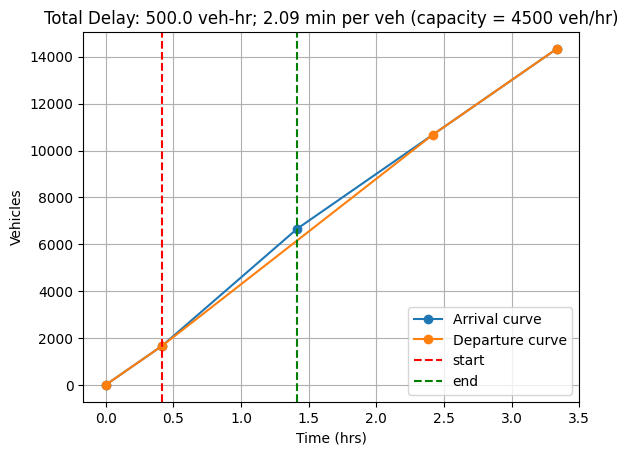

In [9]:
import shapely
from shapely.geometry import LineString, Point

def area_under_curve(points):
    area = 0
    for i in range(len(points)):
        if i == 0:
            area += 0.5 * points[i][0] * points[i][1]
        else:
            width = points[i][0] - points[i-1][0] 
            area += 0.5 * (points[i][1] + points[i-1][1]) * width
    
    return area

def points_from_flow(widths, slopes):
    assert len(widths) == len(slopes)
    heights = []
    for i in range(len(widths)):
        if i == 0:
            heights.append((0, slopes[i] * widths[i]))
        else:
            heights.append((heights[-1][1], heights[-1][1] + slopes[i] * widths[i]))
    
    time = np.cumsum(widths)
    return [(time[i], heights[i][1]) for i in range(len(time))]

points = points_from_flow([25/60, 1, 115/60], [4000, 5000, 4000])
area = area_under_curve(points)
print(f"Area under arrival curve: {area}")

# Intersection of point 0 and slope 4400 and point 1 and slope 4000
cap = 4500
line1 = LineString([points[1], points[2]])
endx = points[2][0]
endy = points[0][1] + (points[2][0] - points[0][0]) * cap
line2 = LineString([points[0], (endx, endy)])
intersection = line1.intersection(line2)
print(intersection.x, intersection.y)
new_points = [points[0], (intersection.x, intersection.y), points[2]]

dep_area = area_under_curve(new_points)
print(f"Area under departure curve: {dep_area}")
print(f"Diff: {area - dep_area} veh-hr")

#plot points and new points using matplotlib
fig, ax = plt.subplots()
ax.plot(*zip((0, 0), *points), marker="o", label="Arrival curve")
ax.plot(*zip((0, 0), *new_points), marker="o", label="Departure curve")
# show gridlines
ax.grid(True)
# draw vertical line at 25/60
ax.axvline(x=25/60, color='r', linestyle='--', label="start")
ax.axvline(x=85/60, color='g', linestyle='--', label="end")
ax.set_title(f"Total Delay: {area - dep_area} veh-hr; {np.round((area - dep_area)/points[-1][1] * 60, 2)} min per veh (capacity = {cap} veh/hr)")
ax.set_xlabel("Time (hrs)")
ax.set_ylabel("Vehicles")
ax.legend()




# Testing METANET Sim

In [ ]:
# Network parameters
tau = 18/3600 #33
p_crit = 37.45 #27.6 #31.1
a = 1.4 #2.5 #2.9
v_free = 120
p_max = 180 #84.5
K = 6.3 #40 #10
eta_high = 11.8#30 #21.3
eta_low = 60
q_capacity = 2200
v_start = 100 # starting speed when vehicles enter the freeway

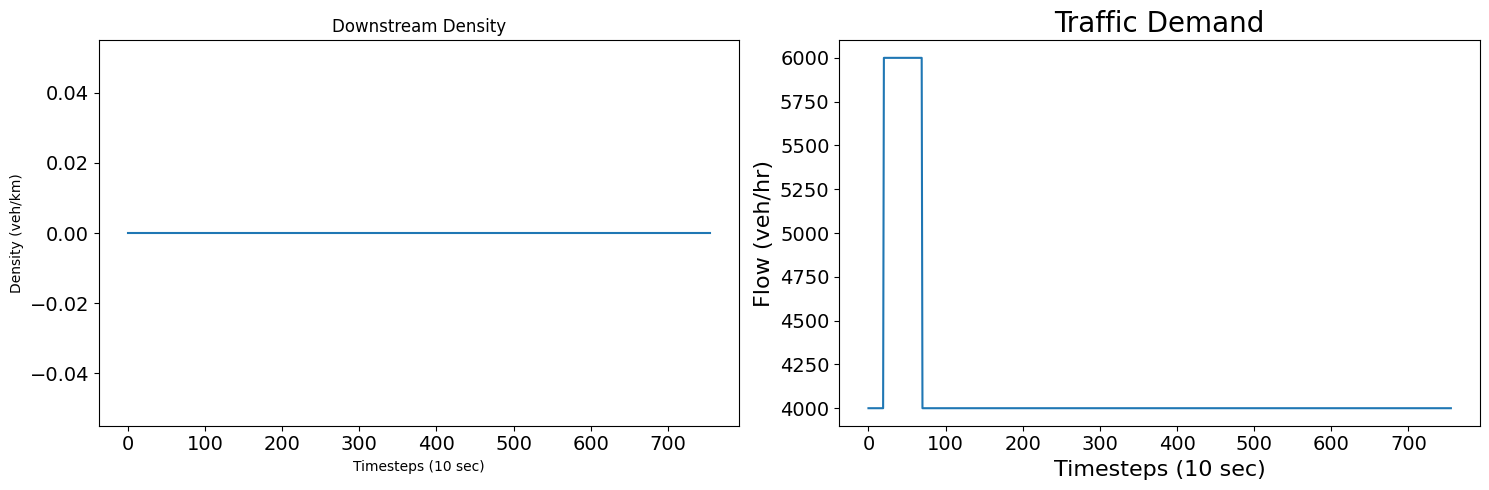

In [ ]:
# Test METANET simulation
import matplotlib.pyplot as plt
pred_horizon = 40
control_horizon = 5
sim_time = 720
time_step = 10/3600
L = 400/1000
time_steps = sim_time + pred_horizon - control_horizon
oscillating = False # Set oscillating to false if want to test a spike in demand instead of stop and go behavior

if oscillating:
    step_per_min = int(60/3600 / (time_step))
    pattern = [0] * 30* step_per_min + [p_crit + 30] * 12 * step_per_min 
    repeat_count = 4 #(time_steps + 1 + len(pattern) - 1) // len(pattern)
    downstream_density = np.array(pattern * repeat_count + [0 for i in range(time_steps)])[:time_steps+1]

    traffic_demand = [4400 for i in range(time_steps + 1)]
else:
    downstream_density = np.full(time_steps + 1, 0)
    traffic_demand = [6000 if i in range(20, 20 + 50) else 4000 for i in range(time_steps + 1)]
    # for i in range(150 + 270, 150 + 270 + 270):
    #     traffic_demand[i] = 2400

    # for i in range(100, 200):
    #     downstream_density[i] = p_crit * 0.9

    # traffic_demand = [3200 if i in range(150, time_steps+1) else 3200 for i in range(time_steps + 1)]


fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(downstream_density)
axs[0].set_title('Downstream Density')
# axs[0].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[0].set_xlabel('Timesteps (10 sec)')
axs[0].set_ylabel('Density (veh/km)')

axs[1].plot(traffic_demand)
axs[1].set_title('Traffic Demand', fontsize=20)
# axs[1].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[1].set_xlabel('Timesteps (10 sec)', fontsize=16)
axs[1].set_ylabel('Flow (veh/hr)', fontsize=16)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


In [ ]:
total_distance = 6
num_segments = int(total_distance/L)

# tau = [
#     0.003079570361892324 for i in range(0,num_segments)
# ]

# K = [
#     6.3014983419163455 for i in range(0,num_segments)
# ]

# eta_high = [
#     11.854341757450348 for i in range(0,num_segments)
# ]


# i24params = {'v_free':124.647, #88.654,
#           'a':1.596,
#           'p_crit':13.977,
#           'q_capacity':1484.2,
#           'K': K,
#           'eta_high': eta_high,
#           'tau':tau}

In [ ]:
from src.sim_params.I24_400mParams import I24_400mParams
from src.sim_params.default import DefaultParams
i24params = DefaultParams(num_segments).get_params()
print(num_segments)

bottleneck_sim_lanes = {i: 4 if i < num_segments - 5 else 2 for i in range(num_segments)}
pipe_sim_lanes = {i: 4 for i in range(num_segments)}
const_vsl = np.array([np.full(num_segments, i24params['v_free']) for i in range(sim_time)])
# p, v, tts, queue = metanet_sim(10/3600, L, (np.array([traffic_demand[0]/(80* sim_lanes[i]) for i in range(num_segments)]), 
#                                             np.full(num_segments, 80), traffic_demand[0], 0), 
#                         const_vsl, traffic_demand, downstream_density, plotting=True, lanes=sim_lanes)
p, v, queue, tts = metanet_sim_params(time_step, L, (np.array([0 for i in range(num_segments)]), np.full(num_segments, 0), traffic_demand[0], 0), 
                        const_vsl, traffic_demand, downstream_density, i24params, plotting=True, lanes=bottleneck_sim_lanes, real_data=False)


print(tts)

15
536.3660398716598


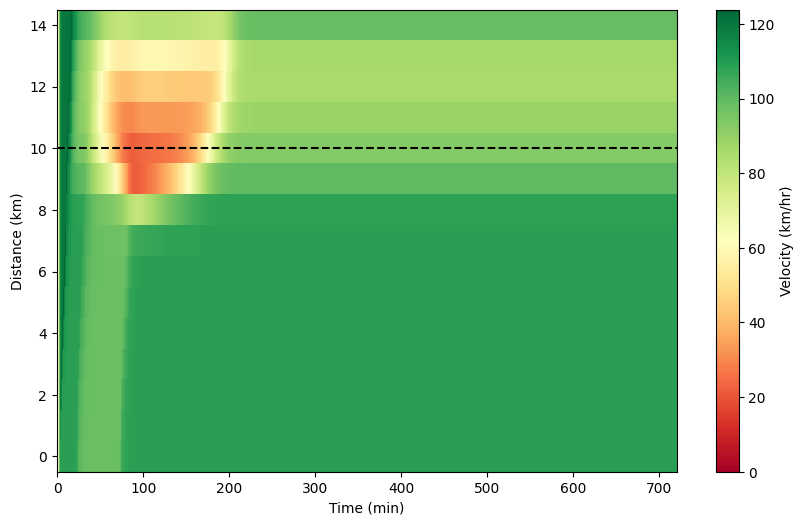

In [ ]:
plt.figure(figsize=(10, 6))

plt.imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation="none")
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
# plt.title(f'No Control: {np.round(tts, 2)} veh-hr, Total Delay: {np.round(tts - ff_ttt, 2)} veh-hr')
plt.axhline(y=num_segments-5, color='k', linestyle='--')

plt.show()



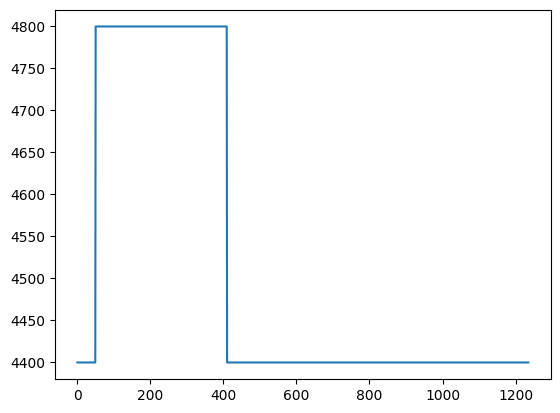

In [ ]:
plt.plot(p*v)

4887.459271870325


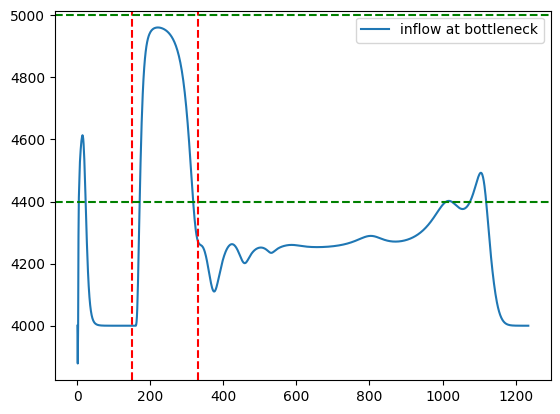

In [ ]:
#Plot flow at cell 10
print(max(p[:, 11]*v[0:, 11]*2))
plt.plot(p[:, 10]*v[0:, 10]*2, label="inflow at bottleneck")
#Plot vertical dotted line at time step 250 and 430
plt.axvline(x=150, color='r', linestyle='--')
plt.axvline(x=330, color='r', linestyle='--')
plt.axhline(y=5000, color='g', linestyle='--')
plt.axhline(y=4400, color='g', linestyle='--')
# plt.plot(queue, label="queue at origin")
plt.legend()

# Run MPC

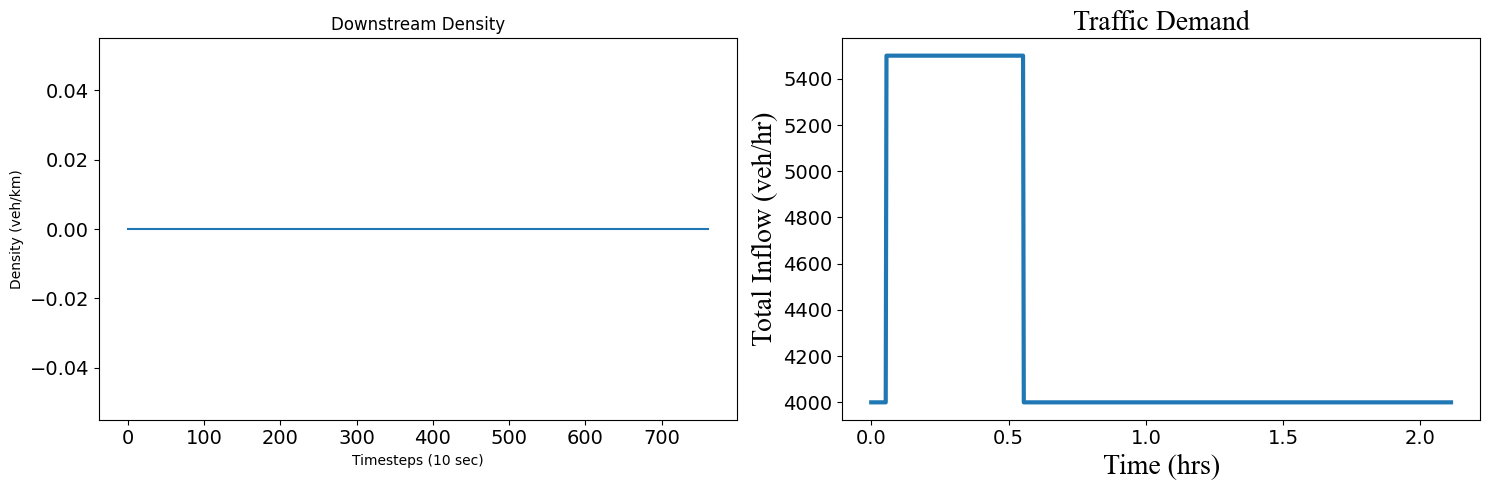

In [3]:
# Test METANET simulation
import matplotlib.pyplot as plt
pred_horizon = 40
control_horizon = 5
sim_time = 720
time_step = 10/3600
L = 400/1000
time_steps = sim_time + pred_horizon
oscillating = False # Set oscillating to false if want to test a spike in demand instead of stop and go behavior
i24_data = False

if oscillating:
    step_per_min = int(60/3600 / (time_step))
    pattern = [0] * 30* step_per_min + [p_crit + 30] * 12 * step_per_min 
    repeat_count = 4 #(time_steps + 1 + len(pattern) - 1) // len(pattern)
    downstream_density = np.array(pattern * repeat_count + [0 for i in range(time_steps)])[:time_steps+1]

    traffic_demand = [4400 for i in range(time_steps + 1)]
elif i24_data:
    downstream_density = np.load('i24_data/downstream_density_400.npy').reshape(-1)
    traffic_demand = np.load('i24_data/initial_flow_400.npy').reshape(-1)

    sim_time = downstream_density.shape[0]
    time_steps = sim_time + pred_horizon - control_horizon
    while len(downstream_density) < time_steps + 1:
        downstream_density = np.append(downstream_density, downstream_density[-1])
        traffic_demand = np.append(traffic_demand, traffic_demand[-1])
else:
    downstream_density = np.full(time_steps + 1, 0)
    traffic_demand = [5500 if i in range(20, 20 + 180) else 4000 for i in range(time_steps + 1)]
    #traffic_demand = [2700 if i in range(50, 50 + 360) else 1000 for i in range(time_steps + 1)]
    # for i in range(150 + 270, 150 + 270 + 270):
    #     traffic_demand[i] = 2400

    # for i in range(100, 200):
    #     downstream_density[i] = p_crit * 0.9

    # traffic_demand = [3200 if i in range(150, time_steps+1) else 3200 for i in range(time_steps + 1)]


fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(downstream_density)
axs[0].set_title('Downstream Density')
# axs[0].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[0].set_xlabel('Timesteps (10 sec)')
axs[0].set_ylabel('Density (veh/km)')

time = np.arange(0, time_steps + 1) * time_step
axs[1].plot(time, traffic_demand, linewidth=3)
axs[1].set_title('Traffic Demand', fontsize=20, fontname='Times New Roman')
axs[1].set_xlabel('Time (hrs)', fontsize=20, fontname='Times New Roman')
axs[1].set_ylabel('Total Inflow (veh/hr)', fontsize=20, fontname='Times New Roman')

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

In [4]:
total_distance = 10
num_segments = int(total_distance/L)

In [ ]:
import os 
import logging
from sympy import divisors
logging.getLogger('pyomo.core').setLevel(logging.ERROR)

np.set_printoptions(suppress=True)

sim_lanes = {i: 4 if i < num_segments-5 else 2 for i in range(num_segments)}
# sim_lanes = {i: 3 if i < num_segments-5 else 2 for i in range(num_segments)}
segment_len = L
m=num_segments
control_zone = np.arange(10, m) # Control zone for VSL
# hold_len = 1 # number of time steps, x * 10 seconds
# assert hold_len <= control_horizon
# assert control_horizon % hold_len == 0

i24params = DefaultParams(num_segments).get_params()

start_traffic_state = (np.full(m, traffic_demand[0]/(sim_lanes[0] * 90)), np.full(m, 90), traffic_demand[0], 0)

no_contrl = metanet_sim_params(time_step, segment_len, start_traffic_state, np.full((sim_time, m), i24params['v_free']), traffic_demand, downstream_density, i24params,
                                real_data=False, lanes=sim_lanes)[1]

init_vsl = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/temporal_safety/safety0.9.csv"))
print(f"No control TTS: {no_contrl} veh-hr")
hold_lens = [a for a in divisors(sim_time) if a <= 60]
filepath = "/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/demand5500/"

for i in [48]:#hold_lens[1:]:

    warm_start_opts = warm_starts_hold_len(i, sim_time, m, i24params, control_zone, path=filepath)
    tts_ws = np.inf
    optimal_vsl = None
    best_ws = None

    control_horizon = max(5, i)
    pred_horizon = max(40, control_horizon)
    time_steps = sim_time + pred_horizon - control_horizon
    for ws in warm_start_opts:
        try:
            vsl = mpc_find_vsl(
                time_steps,
                traffic_demand[0:time_steps+1],
                downstream_density[0:time_steps+1],
                sim_lanes,
                T=time_step,
                l=segment_len,
                num_segments=m,
                pred_horizon=pred_horizon,
                control_horizon=control_horizon,
                hold_length=i,
                initialize_vsl= warm_start_opts[ws],
                init_fixed=None,
                control_one_segment=None,
                control_changepoints=None,
                safety_spatial=None,
                safety_temporal=None,
                params=i24params,
                verbose=False,
                speed_lb=0,
                v_fd_penalty=10000,
                control_zone=control_zone
            )

            vsl_control = metanet_sim_params(time_step, segment_len, start_traffic_state, vsl, traffic_demand, downstream_density, i24params,
                                                lanes=sim_lanes, real_data=False)[1]

            if vsl_control < tts_ws:
                tts_ws = vsl_control
                optimal_vsl = vsl
                best_ws = ws
        except:
            print(f"Warm start {ws} failed for {i}")
            continue

    print(f"TTS with VSL Control for hold len {i} with control zone: {tts_ws} veh-hr")
    print(f"Best warm start: {best_ws}")
    # tts.append(vsl_control) 
    df = pd.DataFrame(optimal_vsl)
    df.to_csv(f"{filepath}/holdlen{i}.csv", index=False)


No control TTS: 1345.2984646131933 veh-hr
MPC Done
MPC Done
MPC Done
MPC Done
MPC Done
TTS with VSL Control for hold len 60 with control zone: 1163.658257147953 veh-hr
Best warm start: opt_vsl


In [ ]:
# Does optimal vsl satisfy the safety constraint?

print("Does optimal VSL satisfy the safety constraint?")
for i in range(optimal_vsl.shape[1]):
    if np.any(np.abs(np.diff(optimal_vsl[:, i])) > 0.9):
        print(f"Optimal VSL at segment {i} violates the safety constraint.")
        print(np.max(np.abs(np.diff(optimal_vsl[:, i]))))

# for i in range(optimal_vsl.shape[0]):
#     if np.any(np.abs(np.diff(optimal_vsl[i, :])) > 10):
#         print(f"Optimal VSL at time step {i} violates the safety constraint.")
#         print(np.max(np.abs(np.diff(optimal_vsl[i, :]))))


Does optimal VSL satisfy the safety constraint?
Optimal VSL at segment 0 violates the safety constraint.
26.412005809791253
Optimal VSL at segment 1 violates the safety constraint.
26.808404061203294
Optimal VSL at segment 2 violates the safety constraint.
56.395494138251784
Optimal VSL at segment 3 violates the safety constraint.
34.33200954832609
Optimal VSL at segment 4 violates the safety constraint.
35.2365061307673
Optimal VSL at segment 5 violates the safety constraint.
27.518415867847878
Optimal VSL at segment 6 violates the safety constraint.
26.176866763348627
Optimal VSL at segment 7 violates the safety constraint.
12.960333300161707
Optimal VSL at segment 8 violates the safety constraint.
10.230085575703356
Optimal VSL at segment 9 violates the safety constraint.
5.938309808792255
Optimal VSL at segment 10 violates the safety constraint.
14.335423326796231
Optimal VSL at segment 11 violates the safety constraint.
15.211754913240888
Optimal VSL at segment 12 violates the saf

In [ ]:
print(optimal_vsl)

[[105.3345173   97.24972312  98.88484936 ...  74.68308857  75.70470221
   83.2988754 ]
 [105.3345173   97.24972312  98.88484936 ...  74.68308857  75.70470221
   83.2988754 ]
 [105.3345173   97.24972312  98.88484936 ...  74.68308857  75.70470221
   83.2988754 ]
 ...
 [108.53887627 108.48391492 107.64326169 ...  72.38110893  73.04417088
   81.40116601]
 [108.53887627 108.48391492 107.64326169 ...  72.38110893  73.04417088
   81.40116601]
 [108.53887627 108.48391492 107.64326169 ...  72.38110893  73.04417088
   81.40116601]]


In [23]:
optimal_vsl = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/holdlen1.csv"))
# time_steps = 1200 + pred_horizon - control_horizon

num_segm = num_segments

# optimal_vsl = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/default_0speed_heatmap/policy_demand5500.0_duration0.5/optimal_vsl.csv"))
#optimal_vsl = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final/holdlength/holdlen6.csv"))
# optimal_vsl = init_vsl
print(vsl.shape)
print(sim_time)

# Calculate free flow travel time
ff_tt = num_segm * segment_len / i24params['v_free'][0]
ff_ttt = np.sum(traffic_demand[0:sim_time]) * 10 / 3600 * ff_tt

no_contrl = metanet_sim(time_step, segment_len, start_traffic_state, np.full((sim_time, num_segm), i24params['v_free'][0]), traffic_demand, downstream_density, lanes=sim_lanes)[1]
vsl_control = metanet_sim_params(time_step, segment_len, start_traffic_state, vsl, traffic_demand, downstream_density, i24params, lanes=sim_lanes, real_data=False)[1]
delay_current = no_contrl - ff_ttt
delay_given_u = vsl_control - ff_ttt
print(f"No control TTS: {no_contrl} veh-hr")
print(f"Optimal Control TTS: {vsl_control} veh-hr")
print(f"Free flow travel time: {ff_ttt}")
print(f"Total Delay: {delay_current} veh-hr")
print(f"Controllable Congestion (i.e. percentage of delay than is controllable): ~{(delay_current - delay_given_u)/delay_current * 100:.2f}%")

(720, 25)
720
No control TTS: 1345.2984646131933 veh-hr
Optimal Control TTS: 1032.487573177816 veh-hr
Free flow travel time: 729.1666666666666
Total Delay: 616.1317979465267 veh-hr
Controllable Congestion (i.e. percentage of delay than is controllable): ~50.77%


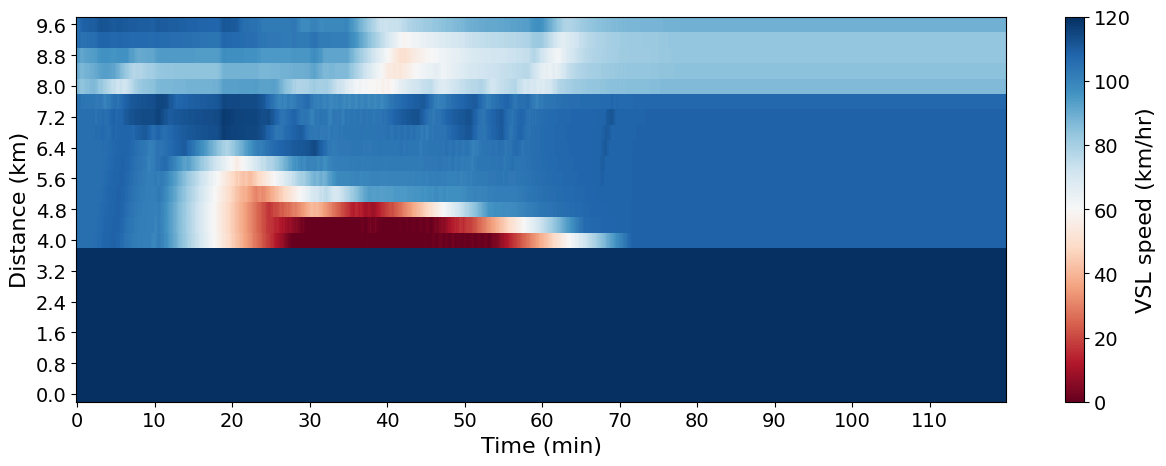

In [24]:
plot_vsls(vsl, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)

720 25


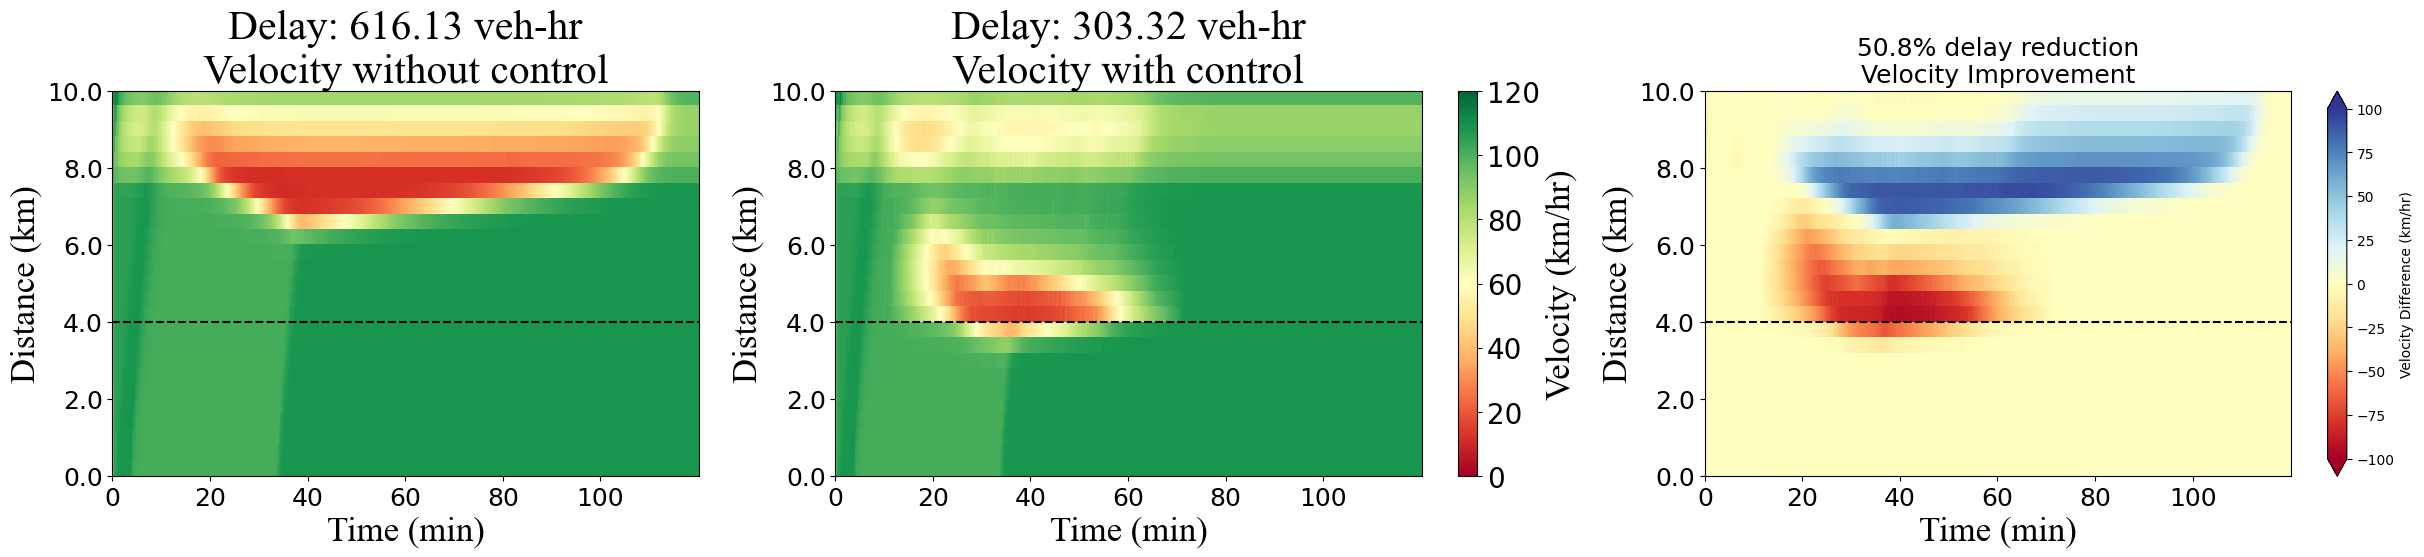

In [25]:
plot_nocontrol_control(traffic_demand, downstream_density, vsl, sim_lanes, i24params['v_free'][0], T=time_step, l=segment_len, plot_p=False, plot_q=False, params=i24params)

# Misc plotting / analysis

In [ ]:
from src.generate_demand import generate_demand
optimal_vsl = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final/holdlength/optimal_vsl_time0.0_distance6_holdlen1_c30_p60_holdlen30.csv"))

time_steps = optimal_vsl.shape[0]
num_segments = optimal_vsl.shape[1]
time_step = 10/3600
seg_len  = 0.4
downstream_density = np.zeros(time_steps + 1)
traffic_demand = generate_demand(time_steps * time_step, time_step, flow_peak=5500, flow_standard=4000)
sim_lanes = {i: 4 if i < 15-5 else 2 for i in range(15)}
i24params = DefaultParams(15).get_params()

tts = metanet_sim_params(time_step, seg_len, (np.full(num_segments, 0), np.full(num_segments, 0), traffic_demand[0], 0), 
                              np.full((time_steps, num_segments), i24params['v_free']), traffic_demand, 
                              np.zeros(time_steps), i24params, lanes=sim_lanes, real_data=False, plotting=False)[1]

tts_2 = metanet_sim_params(time_step, seg_len, (np.full(num_segments, 0), np.full(num_segments, 0), traffic_demand[0], 0), 
                              optimal_vsl, traffic_demand, 
                              np.zeros(time_steps), i24params, lanes=sim_lanes, real_data=False, plotting=False)[1]

print(tts, tts_2)

print(traffic_demand.shape)


1010.6428359006178 1084.3749529209213
(726,)


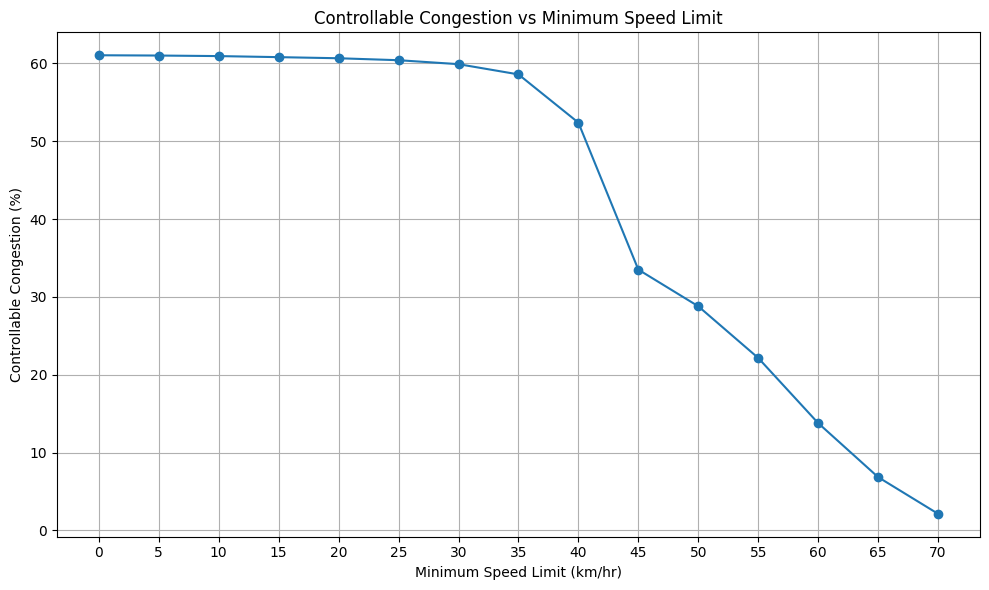

In [ ]:
# Plot controllable congestion vs min speed limit
min_speed_limits = range(0, 75, 5)
controllable_congestion = []
for i in min_speed_limits:
    optimal_vsl = np.array(pd.read_csv(f"results/final/min_speedlimit/optimal_vsl_time{sim_time * time_step//60}_distance{total_distance}_holdlen{1}_c{control_horizon}_p{pred_horizon}_minspeed{i}.csv"))
    vsl_control = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, i24params,
                                      lanes=sim_lanes, real_data=False)[1]
    controllable_congestion.append((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100)
plt.figure(figsize=(10, 6))
plt.plot(min_speed_limits, controllable_congestion, marker='o')
plt.xlabel('Minimum Speed Limit (km/hr)')
plt.ylabel('Controllable Congestion (%)')
plt.title('Controllable Congestion vs Minimum Speed Limit')
plt.grid()
plt.xticks(min_speed_limits)
plt.tight_layout()

/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_1337/760314875.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)


Text(0, 0.5, 'TTS (veh-hr)')

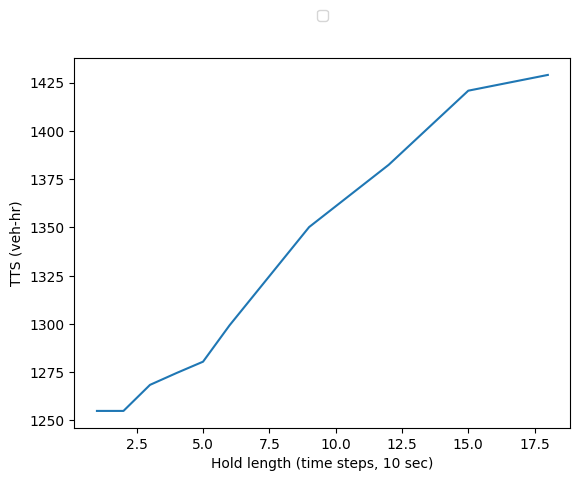

In [ ]:
# Plot TTS from spatial safety
hold_length_dict = {
    1: (6, 40),
    2: (6, 40),
    3: (6, 40),
    4: (8, 40),
    5: (10, 40),
    6: (12, 40),
    9: (18, 40),
    12: (12, 60),
    15: (15, 60),
    18: (18, 60)
}

m = 15
sim_lanes = {i: 4 if i < 10 else 2 for i in range(m)}
# vsl_full_control = np.array(pd.read_csv(f"optimal_vsl_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv"))
# vsl_full = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), vsl_full_control, traffic_demand, downstream_density, lanes=sim_lanes)[1]
vals = []
for i in hold_length_dict.keys():
    optimal_vsl = np.array(pd.read_csv(f"optimal_vsl_{sim_time}_holdlen{i}_c{hold_length_dict[i][0]}_p{hold_length_dict[i][1]}.csv"))
    vsl_control = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
    vals.append(vsl_control)
plt.plot(list(hold_length_dict.keys()), vals)
# plt.axhline(y=no_contrl, color='r', linestyle='--', label='No Control')
# plt.axhline(y=vsl_full, color='g', linestyle='--', label='Maximum Control')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)


plt.xlabel('Hold length (time steps, 10 sec)')
plt.ylabel('TTS (veh-hr)')

In [ ]:
np.set_printoptions(suppress=True)
m = 20
sim_lanes = {i: 4 if i < 15 else 2 for i in range(m)}
time_step = 10/3600
segment_len = 0.5
hold_len = 1 # number of time steps, x * 10 seconds
assert hold_len <= control_horizon
assert control_horizon % hold_len == 0
# TODO what if control horizon is not a multiple of hold_len
# init_vsls = pd.read_csv(f"optimal_vsl_{1200}_holdlen{1}_c{6}_p{40}.csv").to_numpy()
# print(init_vsls.shape)
# init_vsls = np.vstack((init_vsls, np.tile(init_vsls[-1], (time_steps - init_vsls.shape[0], 1))))
# print(init_vsls.shape)
no_contrl = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), np.full((sim_time, m), v_free), traffic_demand, downstream_density, lanes=sim_lanes)[1]
print(f"No control TTS: {no_contrl} veh-hr")

for i in range(0, 15):
    if i <= 1:
        continue
    changepoints = [2, i]
    optimal_vsl = mpc_find_vsl(time_steps, traffic_demand, downstream_density, sim_lanes, T=time_step,
                                l=segment_len, num_segments=m, pred_horizon=pred_horizon, control_horizon=control_horizon, 
                                hold_length=hold_len, initialize_vsl=None, init_fixed=None, 
                                control_one_segment=i, control_changepoints=None)

    vsl_control = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
    print(f"VSL Control for changepoints {changepoints}: {vsl_control} veh-hr")
    df = pd.DataFrame(optimal_vsl)
    #longer_actuationpoint_analysis/changepoint{changepoints}
    df.to_csv(f"submodularity/changepoint{changepoints}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv", index=False)

No control TTS: 2220.157828852299 veh-hr
MPC Done
VSL Control for changepoints [2, 2]: 2183.4955338744094 veh-hr
MPC Done
VSL Control for changepoints [2, 3]: 2158.390152449094 veh-hr
MPC Done
VSL Control for changepoints [2, 4]: 2135.552663275043 veh-hr
MPC Done
VSL Control for changepoints [2, 5]: 2120.906782048472 veh-hr
MPC Done
VSL Control for changepoints [2, 6]: 2103.388552746439 veh-hr
MPC Done
VSL Control for changepoints [2, 7]: 2085.679499676249 veh-hr
MPC Done
VSL Control for changepoints [2, 8]: 2069.9855912533517 veh-hr
MPC Done
VSL Control for changepoints [2, 9]: 2052.8640194205595 veh-hr
MPC Done
VSL Control for changepoints [2, 10]: 2038.0402958898646 veh-hr
MPC Done
VSL Control for changepoints [2, 11]: 2030.687767016705 veh-hr
MPC Done
VSL Control for changepoints [2, 12]: 2035.2403320753297 veh-hr
MPC Done
VSL Control for changepoints [2, 13]: 2065.502126023915 veh-hr
MPC Done
VSL Control for changepoints [2, 14]: 2126.1427317558496 veh-hr


No control TTS: 2220.157828852299 veh-hr
Optimal Control TTS for segment 1: 2123.876091587525 veh-hr ( ~9.39 controllable%)
Optimal Control TTS for segment 2: 2097.5671889737823 veh-hr ( ~11.95 controllable%)
Optimal Control TTS for segment 3: 2079.3988627366707 veh-hr ( ~13.72 controllable%)
Optimal Control TTS for segment 4: 2063.0558466981934 veh-hr ( ~15.32 controllable%)
Optimal Control TTS for segment 5: 2048.3347150429004 veh-hr ( ~16.75 controllable%)
Optimal Control TTS for segment 6: 2035.5155509954163 veh-hr ( ~18.00 controllable%)
Optimal Control TTS for segment 7: 2020.7964218278846 veh-hr ( ~19.44 controllable%)
Optimal Control TTS for segment 8: 2005.1895501300028 veh-hr ( ~20.96 controllable%)
Optimal Control TTS for segment 9: 1989.3197585301025 veh-hr ( ~22.51 controllable%)
Optimal Control TTS for segment 10: 1975.284841487917 veh-hr ( ~23.87 controllable%)
Optimal Control TTS for segment 11: 1971.2590978091757 veh-hr ( ~24.27 controllable%)
Optimal Control TTS for s

Text(0, 0.5, 'Controllable %')

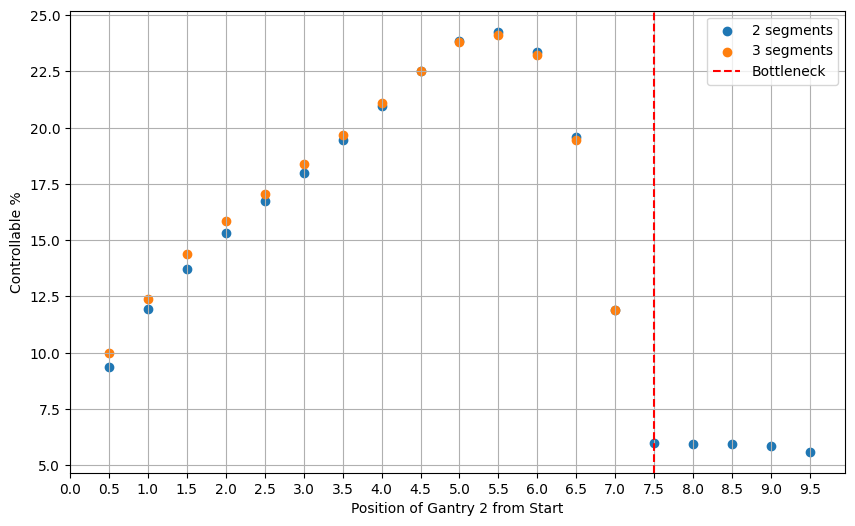

In [ ]:
time_steps = 1200 + pred_horizon - control_horizon
num_segm = 20
sim_lanes = {i: 4 if i < 15 else 2 for i in range(num_segm)}

ff_tt = num_segm * segment_len / v_free
ff_ttt = np.sum(traffic_demand[0:sim_time]) * 10 / 3600 * ff_tt

no_contrl = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), np.full((sim_time, num_segm), v_free), traffic_demand, downstream_density, lanes=sim_lanes)[1]
print(f"No control TTS: {no_contrl} veh-hr")
cc = []
cc_3 = []
for i in range(1, num_segm):
    optimal_vsl = pd.read_csv(f"longer_actuationpoint_analysis/changepoint{[0, i]}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()
    vsl_control = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
    print(f"Optimal Control TTS for segment {i}: {vsl_control} veh-hr ( ~{((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100):.2f} controllable%)")
    cc.append((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100)

for i in range(1, 15):
    optimal_vsl = pd.read_csv(f"longer_actuationpoint_analysis/changepoint{[0, i, 15]}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()
    vsl_control = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
    print(f"Optimal Control TTS for segment {i}: {vsl_control} veh-hr ( ~{((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100):.2f} controllable%)")
    cc_3.append((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100)

plt.figure(figsize=(10, 6))
plt.grid()
plt.scatter((np.arange(1, num_segm)) / 2, cc, label="2 segments")
plt.scatter((np.arange(1, 15)) / 2, cc_3, label="3 segments")
plt.axvline(x=7.5, color='r', linestyle='--', label="Bottleneck")

plt.legend()
#flip x axis
# plt.gca().invert_xaxis()
#show x ticks every 0.5
plt.xticks(np.arange(0, 10, 0.5))
plt.xlabel("Position of Gantry 2 from Start")
plt.ylabel("Controllable %")


In [ ]:
single_control = []
for i in range(15):
    optimal_vsl = pd.read_csv(f"submodularity/changepoint{[i]}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()
    vsl_control = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
    #print(f"Optimal Control TTS for segment {i}: {vsl_control} veh-hr ( ~{((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100):.2f} controllable%)")
    single_control.append((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100)

heatmap = []
for k in [0,1,2]:
    row_k = []
    for i in range(15):
        if i == k:
            row_k.append(single_control[i])
            continue
        changepoint = sorted([i, k])
        optimal_vsl = pd.read_csv(f"submodularity/changepoint{changepoint}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()
        vsl_control = metanet_sim(10/3600, 500/1000, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
        #print(f"Optimal Control TTS for segment {i}: {vsl_control} veh-hr ( ~{((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100):.2f} controllable%)")
        imp = (no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100
        row_k.append(single_control[i] + single_control[k] - imp)
    heatmap.append(np.array(row_k))

heatmap = np.array(heatmap)



[[  5.01118042  -0.34516927  -3.36624219  -5.74416867  -7.83661962
   -9.74380909 -11.47111023 -13.21407675 -15.31376657 -17.13606259
  -18.8412008  -19.4996681  -18.62294646 -14.72785127  -6.95602472]
 [ -0.34516927   4.03045746   0.74951088  -1.90490267  -4.26744532
   -6.11233708  -8.45910128 -10.16153815 -12.35466649 -14.21043461
  -15.98467427 -16.87400199 -16.24902763 -12.93077473  -6.37116382]
 [ -3.36624219   0.74951088   3.57432159   0.52007994  -2.20553746
   -4.10539054  -6.29081822  -8.32528175 -10.43345706 -12.37779304
  -14.15983446 -15.14264043 -14.7092942  -11.67739007  -5.64995806]]
[5.011180415350206, 4.0304574628164005, 3.574321592679038, 2.967681955001365, 2.4685626630872046, 1.996582266473315, 1.5190614539801006, 1.2111087919888426, 0.6329816097907688, 0.35788111701375264, 0.02105078480409928, -0.24493419515794265, -0.2554317445738436, -0.1738443724881365, -0.05845433686708838]


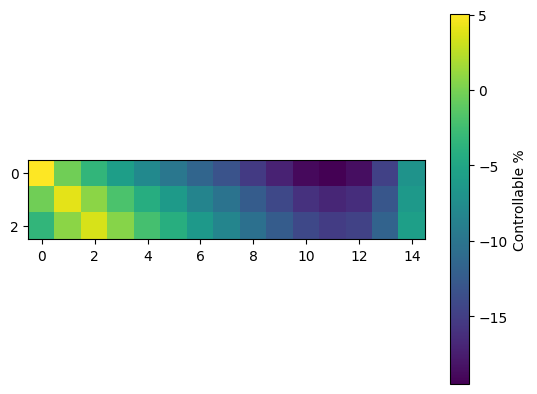

In [ ]:
print(heatmap)

plt.imshow(heatmap)
plt.colorbar(label='Controllable %')

print(single_control)

In [ ]:
time_steps = 1200 + pred_horizon - control_horizon
num_segm = 15
#1.8754152349
#1.8754166
print(optimal_vsl.shape)
print(time_steps)
ff_tt = num_segm * segment_len / v_free
ff_ttt = np.sum(traffic_demand[0:sim_time]) * 10 / 3600 * ff_tt
no_contrl = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), np.full((sim_time, num_segm), v_free), traffic_demand, downstream_density, lanes=sim_lanes)[1]
vsl_control = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes)[1]
print(np.max(optimal_vsl))
print(f"No control TTS: {no_contrl} veh-hr")
print(f"Optimal Control TTS: {vsl_control} veh-hr")
print(f"{ff_ttt}")
print(f"Total Delay: {no_contrl - ff_ttt} veh-hr")
print(f"Controllable Congestion (i.e. percentage of delay than is controllable): ~{((no_contrl - vsl_control) / (no_contrl - ff_ttt) * 100):.2f}%")


(1200, 15)
1235
118.95650479456842
No control TTS: 1312.9941751460574 veh-hr
Optimal Control TTS: 1226.1270022260828 veh-hr
916.6666666666666
Total Delay: 396.32750847939076 veh-hr
Controllable Congestion (i.e. percentage of delay than is controllable): ~21.92%


2474.011733725332


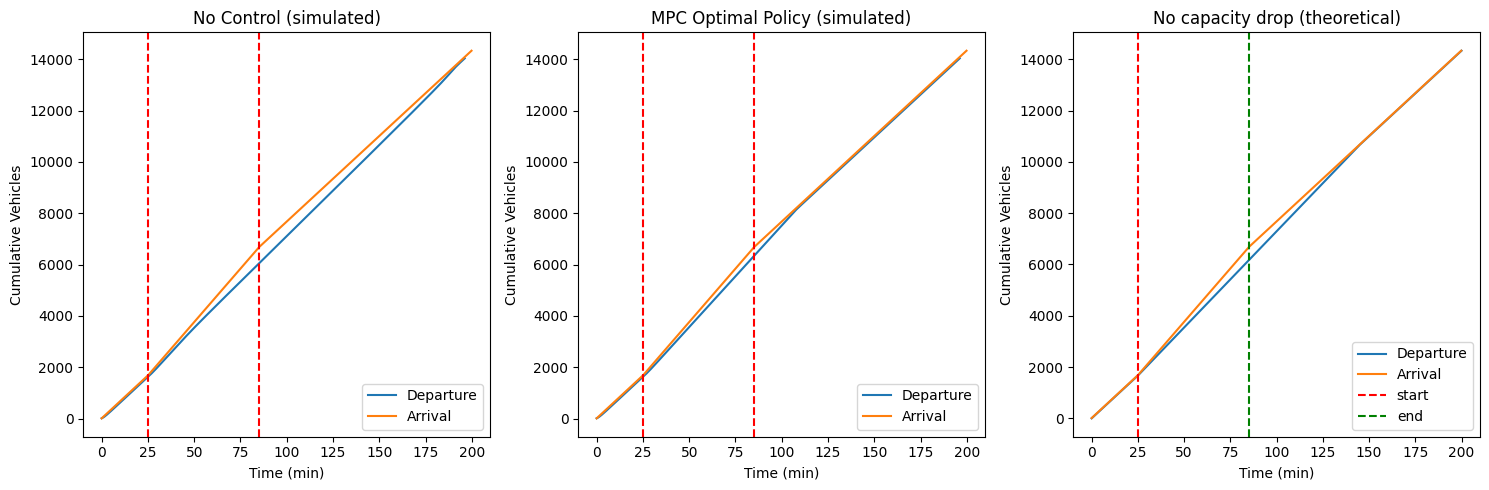

In [ ]:
noctrl_p, noctrl_v, _, _ = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), np.full((sim_time, num_segm), v_free), traffic_demand, downstream_density, lanes=sim_lanes, plotting=True)
noctrl_dep = noctrl_p[:, -1] * noctrl_v[:, -1] * 2 * time_step
noctrl_dep = np.cumsum(noctrl_dep[0:1200])
noctrl_arr = np.cumsum(traffic_demand[0:1200]) * time_step

opt_p, opt_v, _, _ = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, lanes=sim_lanes, plotting=True)
opt_dep = opt_p[:, -1] * opt_v[:, -1] * 2 * time_step
opt_dep = np.cumsum(opt_dep[0:1200])
opt_arr = np.cumsum(traffic_demand[0:1200]) * time_step
print(np.max(opt_v * opt_p))
# print(np.max(opt_p[:, -1] * opt_v[:, -1]))

show_delay = True
# Two plots side by side
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(np.arange(0, 1200-22 if show_delay else 1200) * 10/60, noctrl_dep[22:] if show_delay else noctrl_dep, label="Departure")
axs[0].plot(np.arange(0, 1200) * 10/60, noctrl_arr, label="Arrival")
# vertical line at 25 min and 85 min
axs[0].axvline(x=25, color='r', linestyle='--')
axs[0].axvline(x=85, color='r', linestyle='--')
axs[0].set_xlabel('Time (min)')
axs[0].set_ylabel('Cumulative Vehicles')
axs[0].set_title('No Control (simulated)')
axs[0].legend()

axs[1].plot(np.arange(0, 1200-22 if show_delay else 1200) * 10/60, opt_dep[22:] if show_delay else noctrl_dep, label="Departure")
axs[1].plot(np.arange(0, 1200) * 10/60, opt_arr, label="Arrival")
# vertical line at 25 min and 85 min
axs[1].axvline(x=25, color='r', linestyle='--')
axs[1].axvline(x=85, color='r', linestyle='--')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Cumulative Vehicles')
axs[1].set_title('MPC Optimal Policy (simulated)')
axs[1].legend()

new_points_min = [(x[0]*60, x[1]) for x in new_points]
axs[2].plot(*zip((0, 0), *new_points_min), label="Departure")
axs[2].plot(np.arange(0, 1200) * 10/60, opt_arr, label="Arrival")
axs[2].axvline(x=25, color='r', linestyle='--', label="start")
axs[2].axvline(x=85, color='g', linestyle='--', label="end")
axs[2].set_xlabel('Time (min)')
axs[2].set_ylabel('Cumulative Vehicles')
axs[2].set_title('No capacity drop (theoretical)')
axs[2].legend()

plt.tight_layout()
plt.show()


18015
0 0
[]
[]
(array([], dtype=int64), array([], dtype=int64))


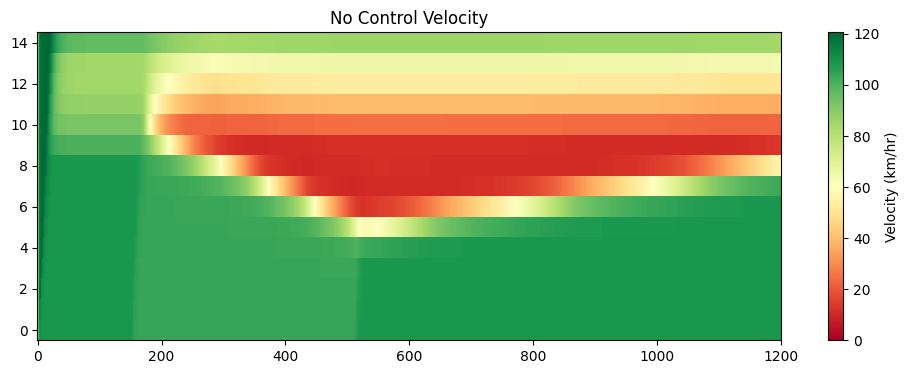

In [ ]:
noctrl_p, noctrl_v, _, _ = metanet_sim(10/3600, 500/1000, (np.full(num_segm, 0), np.full(num_segm, 0), traffic_demand[0], 0), np.full((sim_time, num_segm), v_free), traffic_demand, downstream_density, lanes=sim_lanes, plotting=True)
# print(np.max(noctrl_p))
# print(np.max(noctrl_v))
flows = noctrl_p * noctrl_v
print(flows.shape[0] * flows.shape[1])
ex_idx = np.where(flows >  q_capacity + 1)
ex_v = noctrl_v[ex_idx]
ex_p = noctrl_p[ex_idx]
print(len(ex_v), len(ex_p))
print(ex_v)
print(ex_p)
print(ex_idx)

#Plot noctrl_v in a heatmap and show where it exceeds q_capacity
plt.figure(figsize=(12, 4))
plt.imshow(noctrl_v.T, cmap='RdYlGn', aspect='auto', interpolation="none")
plt.colorbar(label='Velocity (km/hr)')
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('No Control Velocity')
# Set boxes to red where velocity exceeds q_capacity
for i, j in zip(ex_idx[0], ex_idx[1]):
    plt.gca().add_patch(plt.Rectangle((i-0.5, j-0.5), 1, 1, fill=False, edgecolor='blue', lw=1))
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import pandas as pd
# Save optimal control to csv file
df = pd.DataFrame(optimal_vsl)
df.to_csv(f"optimal_vsl_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv", index=False)

(1200, 20)
(1200, 20)


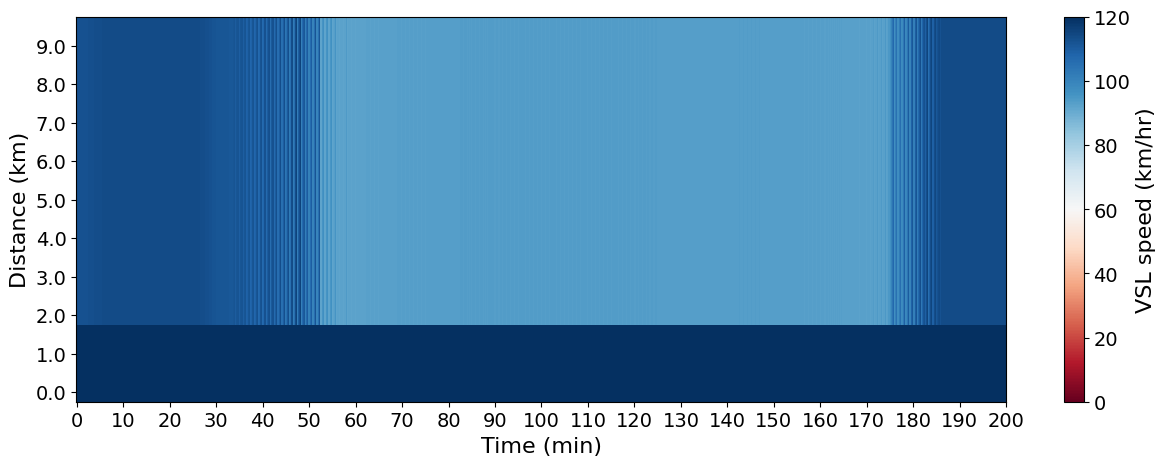

In [ ]:
# optimal_vsl = np.genfromtxt(f"optimal_vsl_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv", delimiter=',')
optimal_vsl = pd.read_csv(f"submodularity/changepoint{[4]}_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()
# optimal_vsl = pd.read_csv(f"optimal_vsl_longer_1200_holdlen1_c5_p40.csv").to_numpy()
print(optimal_vsl.shape)
extra_segm = 0
long_horizon_vsl = np.hstack((np.ones((sim_time, extra_segm)) * v_free, optimal_vsl, ))
print(long_horizon_vsl.shape)
plot_vsls(long_horizon_vsl, time_steps, num_segm+extra_segm, v_free, T=time_step, l=segment_len)

1200 15


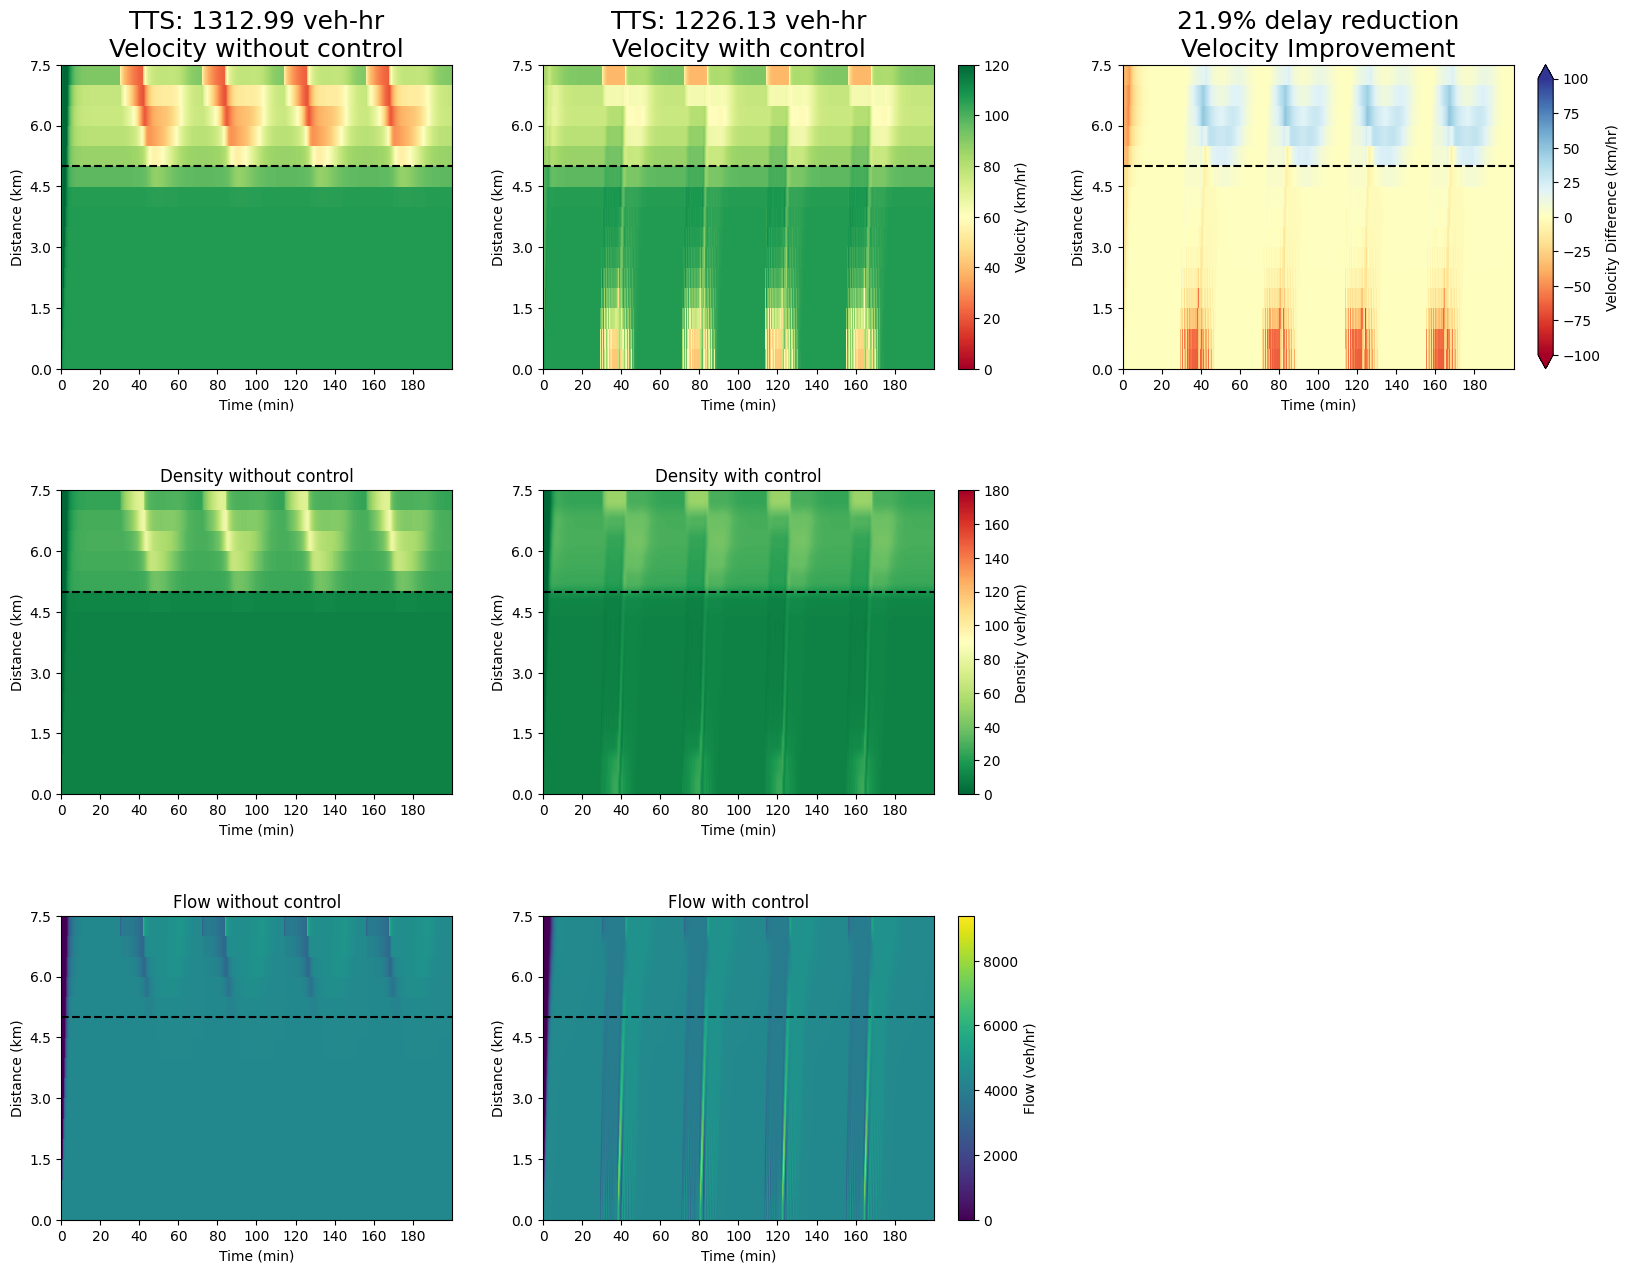

In [ ]:
# longer_sim_lanes = {i: 4 if i < (10 + extra_segm) else 2 for i in range(num_segm + extra_segm)}
plot_nocontrol_control(traffic_demand, downstream_density, long_horizon_vsl, sim_lanes, v_free, T=time_step, l=segment_len, plot_p=True, plot_q=True)

In [ ]:
optimal_vsl = pd.read_csv(f"optimal_vsl_{1200}_holdlen{1}_c{6}_p{40}.csv").to_numpy()

1200 15


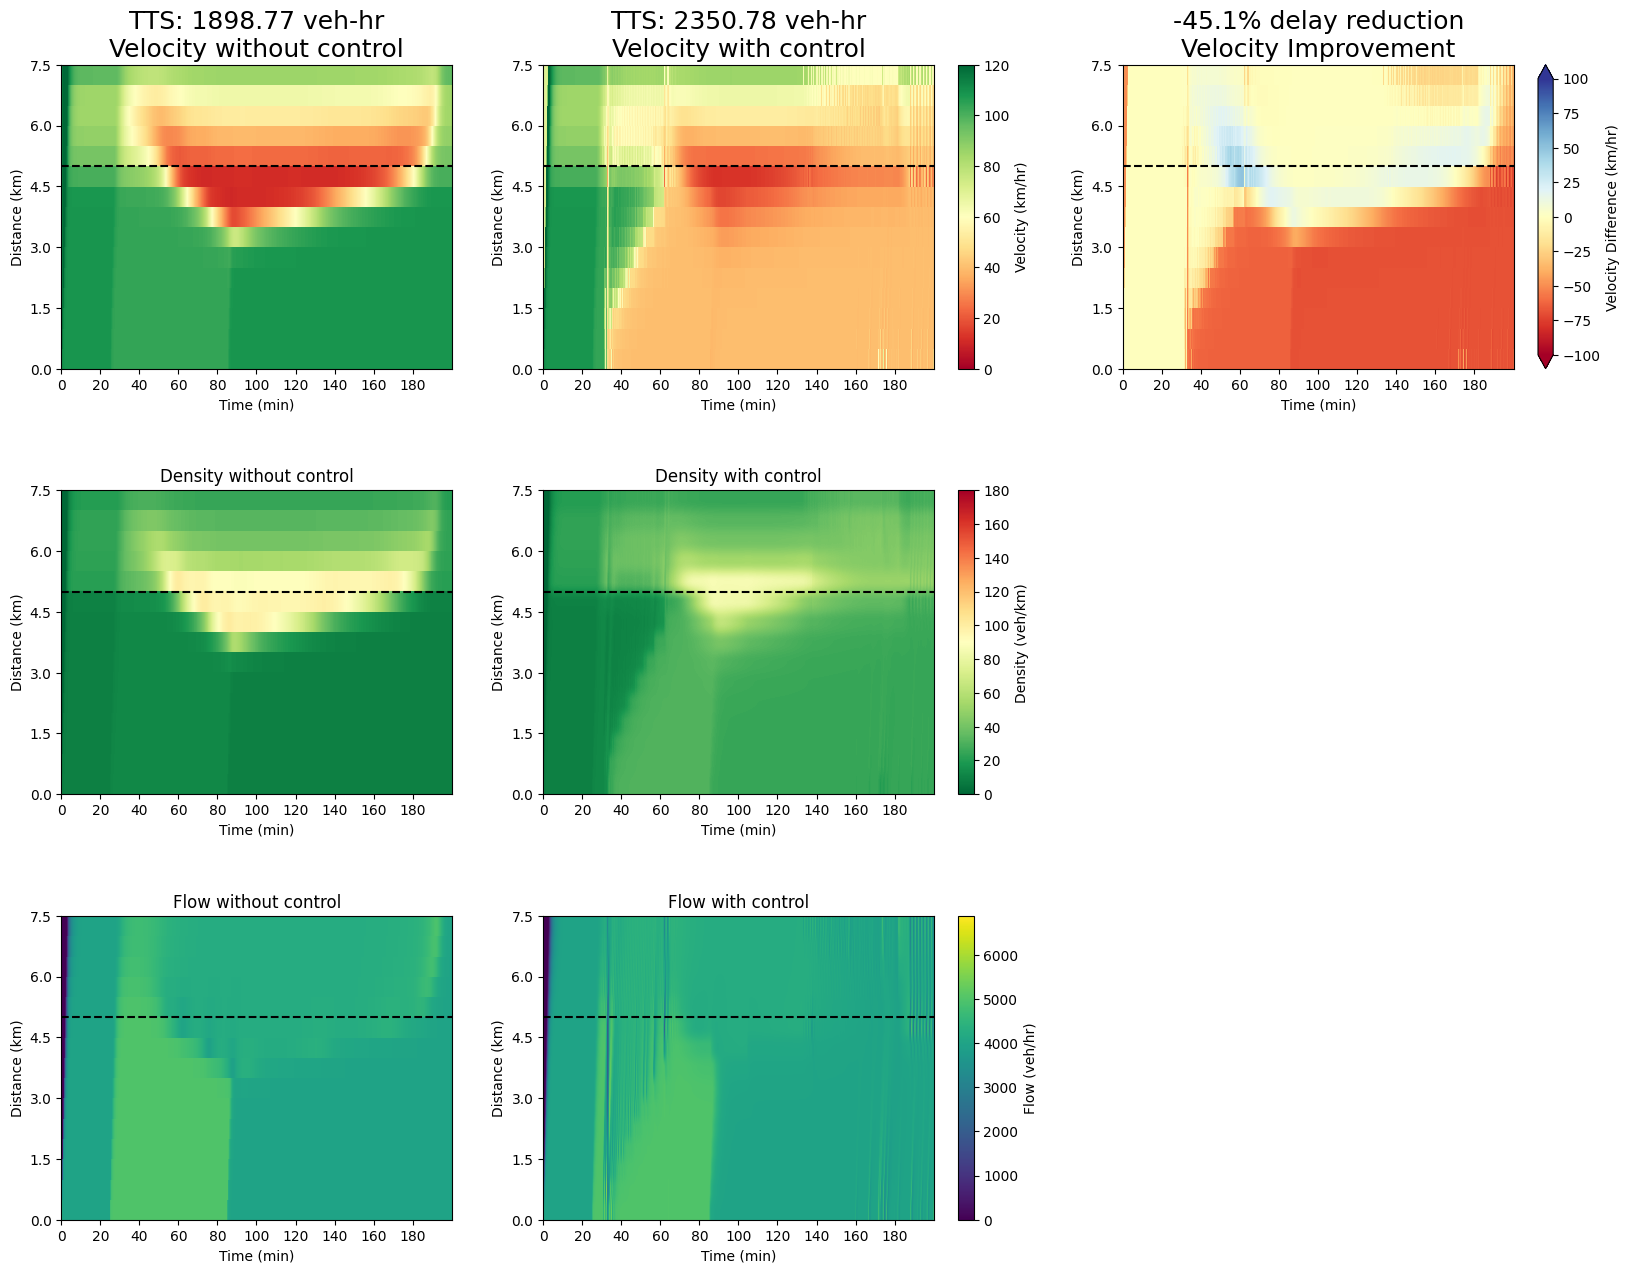

In [ ]:
plot_nocontrol_control(traffic_demand, downstream_density, optimal_vsl, sim_lanes, v_free, T=time_step, l=segment_len, plot_p=True, plot_q=True)
# Check why wave starts at boundary

{0: 4, 1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2}


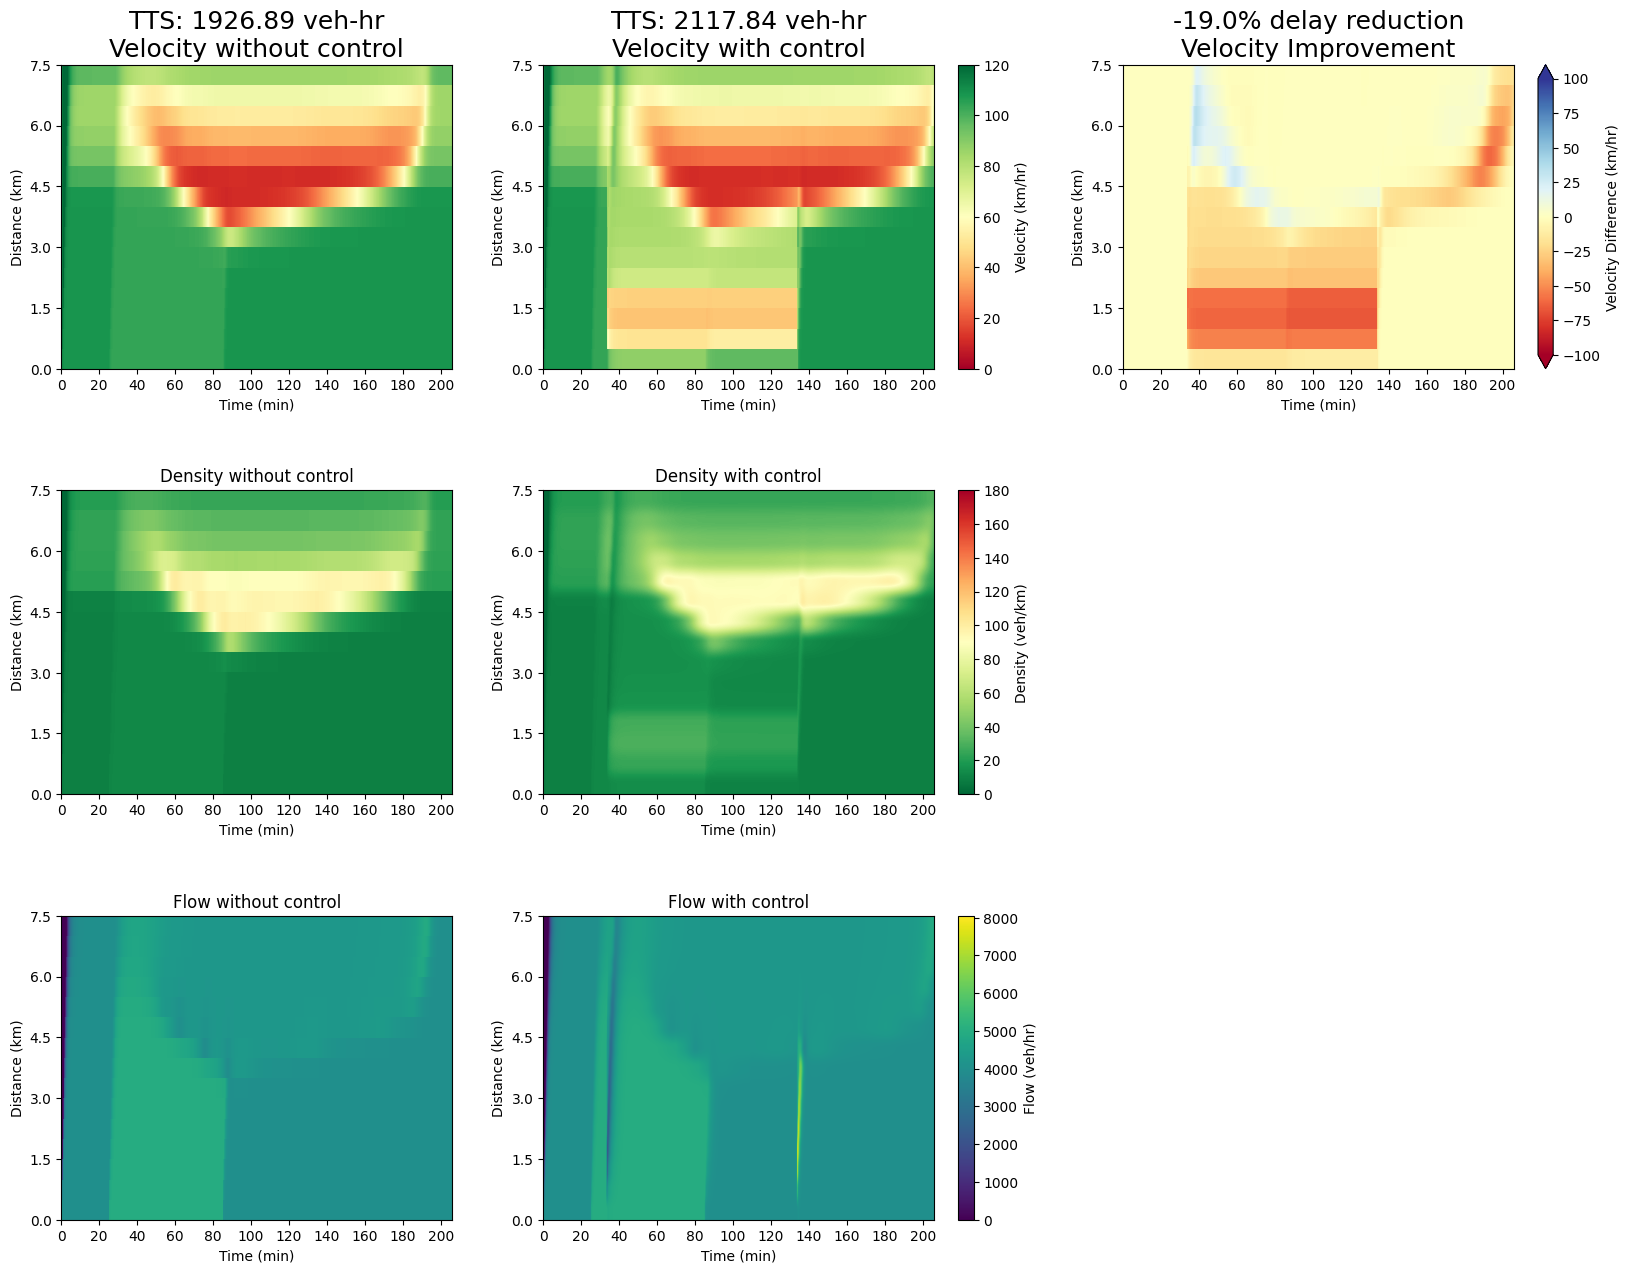

In [ ]:
def find_zone_vsl(i):
    if i < 4 and i >= 1:
        return 0.3 * v_free
    elif i < 9 and i >= 5:
        return 0.7*v_free
    elif i >= 9:
        return v_free
    else:
        return v_free 
    
print(sim_lanes)
    
rule_based_vsl = np.array([[find_zone_vsl(j) if i >= 200 and i <= 800 else v_free for j in range(num_segm)] for i in range(time_steps)])
plot_nocontrol_control(traffic_demand, downstream_density, rule_based_vsl, sim_lanes, v_free, T=time_step, l=segment_len, plot_p=True, plot_q=True)


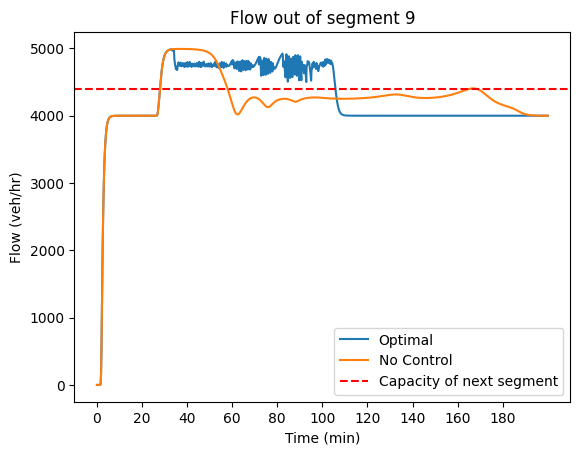

In [ ]:
plot_outflow(traffic_demand, downstream_density, optimal_vsl, sim_lanes, v_free, T=time_step, l=segment_len, seg=9)
#Add line for capacity

In [ ]:
# Read speed limit from 0 to 50 csv
x = np.arange(0, 105, 5)
y = []

ff_tt = sum(traffic_demand[0:sim_time]) * 10 / 3600 * total_distance / i24params['v_free']
print(ff_tt)
no_contrl = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), np.full((sim_time, num_segments), i24params['v_free']), traffic_demand, downstream_density, i24params,
                                lanes=sim_lanes, real_data=False)[1]
delay = no_contrl - ff_tt
for i in range(0, 105, 5):
    if i < 55:
        speed_limit_df = pd.read_csv(f'results/speedlimit{i}_time{0.0}_distance6_holdlen1_c5_p40.csv').to_numpy()
    if i >= 55:
        speed_limit_df = pd.read_csv(f'results/speedlimit40_time{0.0}_distance6_holdlen1_c5_p40.csv').to_numpy()
        speed_limit_df = np.where(speed_limit_df < i, i, speed_limit_df)


    vsl_control = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), speed_limit_df, traffic_demand, downstream_density, i24params,
                                    lanes=sim_lanes, real_data=False)[1]
    new_delay = vsl_control - ff_tt
    y.append((delay - new_delay) / delay * 100)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, marker='o')
plt.ylim(0, 65)
plt.grid()
plt.xlabel('Minimum Possible Speed Limit (km/hr)')
plt.ylabel('Controllable Congestion (%)')
# plt.axhline(y=no_contrl, color='r', linestyle='--', label='No Control')
plt.show()

[437.5 437.5 437.5 437.5 437.5 437.5 437.5 437.5 437.5 437.5 437.5 437.5
 437.5 437.5 437.5]


IndexError: index 721 is out of bounds for axis 0 with size 721

## Hold Length Transfer Init

In [ ]:
import os
hold_length_dict = {
    1: (6, 40),
    2: (6, 40),
    3: (6, 30),
    4: (8, 40),
    5: (10, 30),
    6: (12, 40),
    9: (18, 40),
    12: (12, 60),
    15: (15, 60),
    18: (18, 60)
}

hold_lens = np.array(list(hold_length_dict.keys()))

for hold_len_target in [1]:
    # save_dir = f"holdlen_TL/policy_holdlen_{hold_len_target}"

    # if not os.path.exists(save_dir):
    #     os.mkdir(save_dir)

    pred_horizon = hold_length_dict[hold_len_target][1]
    control_horizon = hold_length_dict[hold_len_target][0]
    sim_time = 1200
    time_steps = sim_time + pred_horizon - control_horizon
    assert hold_len_target <= control_horizon
    assert control_horizon % hold_len_target == 0

    traffic_demand = [5000 if i in range(150, 150 + 360) else 4000 for i in range(time_steps + 1)]
    steady_density = 0
    downstream_density = np.full(time_steps + 1, steady_density)

    m = 15
    sim_lanes = {i: 4 if i < 10 else 2 for i in range(m)}
    time_step = 10/3600
    segment_len = 0.5

    for hold_len_source in [2]:
        print(f"Optimizing for hold length {hold_len_target} by initializing with hold length {hold_len_source}")
        init_vsls = pd.read_csv(f"optimal_vsl_{sim_time}_holdlen{hold_len_source}_c{hold_length_dict[hold_len_source][0]}_p{hold_length_dict[hold_len_source][1]}.csv").to_numpy()
        # Pad init_vsls with last value so it is the same length as time_steps
        init_vsls = np.vstack((init_vsls, np.tile(init_vsls[-1], (time_steps - init_vsls.shape[0], 1))))
        assert init_vsls.shape == (time_steps, m)

        optimal_vsl = mpc_find_vsl(time_steps, traffic_demand, downstream_density, sim_lanes, T=time_step,
                                l=segment_len, num_segments=m, pred_horizon=pred_horizon, control_horizon=control_horizon, hold_length=hold_len_target, initialize_vsl=init_vsls)
        
        df = pd.DataFrame(optimal_vsl)
        df.to_csv(f"optimal_vsl_{sim_time}_holdlen{hold_len_source}_c{hold_length_dict[hold_len_source][0]}_p{hold_length_dict[hold_len_source][1]}.csv", index=False)


Optimizing for hold length 1 by initializing with hold length 2
WARNING (W1002): Setting Var 'v[1,6]' to a numeric value `121.0357122230111`
outside the bounds (1e-20, 120).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[3,8]' to a numeric value `120.25570638431108`
outside the bounds (1e-20, 120).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[4,7]' to a numeric value `120.23226035377724`
outside the bounds (1e-20, 120).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[5,8]' to a numeric value `120.10934965938642`
outside the bounds (1e-20, 120).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[6,9]' to a numeric value `120.18127541179814`
outside the bounds (1e-20, 120).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[